# Cell embeddings with BrainBeacon

This tutorial generates zero-shot cell embeddings with the pretrained BrainBeacon Stage 1 and Stage 2 checkpoints. The example uses the human Xenium XE4 sample from Kotah et al.

- Dataset record: [Zenodo 15425563](https://zenodo.org/records/15425563)
- Direct archive: [XE4.zip](https://zenodo.org/records/15425563/files/XE4.zip?download=1)
- Checkpoint setup: see [Pretrained weights](../../README.md#pretrained-weights)

The main workflow is: prepare an AnnData object, set the paths and inference parameters, and call `run_brainbeacon_pipeline`. UMAP, spatial visualization, and clustering metrics are optional downstream steps.


## 1. Imports and device

Run this notebook from a BrainBeacon checkout with its environment activated. A CUDA GPU is recommended for the full XE4 sample.


In [1]:
import os

# To select a specific GPU, uncomment this before importing torch.
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import torch
from IPython.display import display

from brainbeacon.pipeline.cell_embedding import run_brainbeacon_pipeline

# Keep notebook figures legible even when Jupyter uses a dark interface theme.
sc.settings.set_figure_params(
    dpi=120,
    dpi_save=300,
    figsize=(6, 6),
    fontsize=11,
    facecolor="white",
    transparent=False,
    ipython_format="png",
)
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "savefig.transparent": False,
        "text.color": "black",
        "axes.labelcolor": "black",
        "xtick.color": "black",
        "ytick.color": "black",
    }
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"Using GPU: {torch.cuda.get_device_name(torch.cuda.current_device())}")


Using device: cuda
Using GPU: Tesla V100-SXM2-16GB


## 2. Paths and sample selection

Set `project_root` to the BrainBeacon repository root. The remaining paths follow the same `os.path.join` pattern used by the downstream scripts.

The default data path points to the combined benchmark AnnData used on our server. A standalone XE4 AnnData file also works; in that case, set `data_path` to that file.


In [2]:
project_root = "/raid/zhangchengming/BrainBeacon-master"
data_path = os.path.join(
    project_root,
    "data",
    "Xenium_Human_Kotah2025",
    "processed",
    "Kotah2025.h5ad",
)

slice_id = "Kotah2025_XE4"
species = "human"
assay = "xenium"

gene_dict_path = os.path.join(project_root, "prior_knowledge", "gene_dict.h5ad")
stage1_ckpt_path = os.path.join(project_root, "pretrained", "stage1_fix_step_800000.pt")
stage2_ckpt_path = os.path.join(project_root, "pretrained", "stage2_ep280_200.pt")
output_dir = os.path.join(
    project_root,
    "downstream_tasks",
    "cell_clustering",
    "outputs",
    "tutorial_xe4",
)
output_prefix = "kotah2025_xe4_brainbeacon"
os.makedirs(output_dir, exist_ok=True)

for path in [data_path, gene_dict_path, stage1_ckpt_path, stage2_ckpt_path]:
    if not os.path.exists(path):
        raise FileNotFoundError(path)

print("Project root:", project_root)
print("Input data:", data_path)
print("Output directory:", output_dir)


Project root: /raid/zhangchengming/BrainBeacon-master
Input data: /raid/zhangchengming/BrainBeacon-master/data/Xenium_Human_Kotah2025/processed/Kotah2025.h5ad
Output directory: /raid/zhangchengming/BrainBeacon-master/downstream_tasks/cell_clustering/outputs/tutorial_xe4


## 3. Load and validate the AnnData input

BrainBeacon expects raw counts, Ensembl gene IDs in `adata.var_names`, and two-dimensional coordinates in `adata.obsm['spatial']`. The optional cell-type labels are used only for visualization and evaluation after inference.

When a combined Kotah2025 object is supplied, this cell selects XE4. When a standalone XE4 file is supplied, it assigns the requested slice identifier directly.


In [3]:
# Backed mode avoids loading every slice when data_path contains a combined dataset.
adata_all = sc.read_h5ad(data_path, backed="r")

if "slice" in adata_all.obs:
    available_slices = adata_all.obs["slice"].astype(str)
    if slice_id in set(available_slices):
        selected_slice = slice_id
    else:
        xe4_matches = [value for value in available_slices.unique() if value.upper().endswith("XE4")]
        if len(xe4_matches) == 1:
            selected_slice = xe4_matches[0]
        elif available_slices.nunique() == 1:
            selected_slice = available_slices.iloc[0]
        else:
            raise ValueError(f"Could not identify XE4. Available slices: {sorted(available_slices.unique())}")
    adata = adata_all[available_slices == selected_slice].to_memory()
else:
    adata = adata_all.to_memory()

adata_all.file.close()
del adata_all
adata.obs["slice"] = slice_id
adata.obs_names_make_unique()

# Use raw counts when they are provided in a dedicated layer.
if "counts" in adata.layers:
    adata.X = adata.layers["counts"].copy()

# Recover spatial coordinates from common Xenium columns when necessary.
if "spatial" not in adata.obsm:
    coordinate_pairs = [("x_centroid", "y_centroid"), ("x", "y")]
    for x_key, y_key in coordinate_pairs:
        if x_key in adata.obs and y_key in adata.obs:
            adata.obsm["spatial"] = adata.obs[[x_key, y_key]].to_numpy(dtype=np.float32)
            break
if "spatial" not in adata.obsm:
    raise KeyError("The input AnnData must contain `obsm['spatial']` or coordinate columns.")

spatial = np.asarray(adata.obsm["spatial"])
if spatial.ndim != 2 or spatial.shape[1] < 2:
    raise ValueError(f"Expected spatial coordinates with shape (n_cells, >=2), got {spatial.shape}.")
valid_spatial = np.isfinite(spatial[:, :2]).all(axis=1)
adata = adata[valid_spatial].copy()
adata.obsm["spatial"] = np.asarray(adata.obsm["spatial"])[:, :2].astype(np.float32)

# BrainBeacon tokenization requires Ensembl IDs as var_names.
if not adata.var_names.astype(str).str.startswith("ENS").all():
    gene_id_key = next((key for key in ["ensembl_id", "gene_ids"] if key in adata.var), None)
    if gene_id_key is None:
        raise ValueError("Provide Ensembl IDs in var_names, var['ensembl_id'], or var['gene_ids'].")
    gene_ids = adata.var[gene_id_key].astype(str)
    valid_genes = gene_ids.str.startswith("ENS").to_numpy()
    adata = adata[:, valid_genes].copy()
    adata.var_names = gene_ids.loc[valid_genes].to_numpy()

if adata.var_names.has_duplicates:
    adata = adata[:, ~adata.var_names.duplicated()].copy()

# Match the minimum QC used by the tokenization pipeline before inference.
sc.pp.filter_cells(adata, min_genes=3)
sc.pp.filter_genes(adata, min_cells=3)

label_key = next((key for key in ["cell_label", "celltype_broad", "cell_type"] if key in adata.obs), None)
print(adata)
print("Label key used only for downstream display/evaluation:", label_key)
print("Spatial shape:", adata.obsm["spatial"].shape)


/raid/zhangchengming/miniconda3/envs/brainbeacon_dgx1/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 123298 × 266
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'leiden', 'celltype_broad', 'platform', 'disease_state', 'tissue', 'cell_label', 'species', 'slice', 'split', 'file', 'genomic_control_counts', 'nucleus_count', 'segmentation_method', 'n_genes'
    var: 'ensembl_id', 'feature_types', 'genome', 'gene_symbol', 'n_cells'
    obsm: 'X_pca', 'X_umap', 'spatial'
    layers: 'counts'
Label key used only for downstream display/evaluation: cell_label
Spatial shape: (123298, 2)


## 4. Configure zero-shot inference

These settings reproduce the intended pretrained inference path. In particular, `do_fit=False` keeps both pretrained stages frozen. Set `force_tokenize=True` only when the input data or Stage 1 tokenization settings have changed and cached outputs must be regenerated.


In [4]:
stage1_config = {
    "n_hvg": 5000,
    "use_hvg": True,
    "weight_mode": "expression",
    "cd_weight": 0.02,
    "use_homo_emb": True,
    "use_esm_emb": True,
    "use_rna_type_emb": True,
    "use_gene_deviation": True,
    "use_cell_density": True,
    "use_dev_abs": True,
    "radius_map": "pretrain",
    "force_tokenize": False,
}

stage2_config = {
    "sampling_mode": "spatial",
    "use_patch": True,
    "eval_use_patch": True,
    "slice_num": 2000,
    "dataset_num": 200,
    "platform_num": 5,
}


## 5. Generate BrainBeacon embeddings

The full two-stage pipeline is called once. No target-dataset fitting is performed in this tutorial.


In [5]:
adata = run_brainbeacon_pipeline(
    adata=adata,
    species=species,
    assay=assay,
    gene_dict_path=gene_dict_path,
    stage1_ckpt_path=stage1_ckpt_path,
    stage2_ckpt_path=stage2_ckpt_path,
    output_dir=output_dir,
    output_prefix=output_prefix,
    stage1_config=stage1_config,
    stage2_config=stage2_config,
    do_fit=False,
    fit_epochs=0,
    stage1_mode="memory",
    save_model=False,
    device=device,
    seed=42,
    deterministic=True,
)


====== Stage1: Inference (memory) ======
Skipping stage1 inference. Found existing file: /raid/zhangchengming/BrainBeacon-master/downstream_tasks/cell_clustering/outputs/tutorial_xe4/kotah2025_xe4_brainbeacon_stage1_embeddings.npz
[Stage1 total - memory] Time cost: 2.85 sec
[INFO] Gene list size: 92076
[INFO] Loading stage2 pretrained checkpoint: /raid/zhangchengming/BrainBeacon-master/pretrained/stage2_ep280_200.pt
[INFO] Skipped parameters (3): ['decoder.covariate_layers.0.dataset_cov.0.weight', 'decoder.covariate_layers.0.platform_cov.0.weight', 'decoder.covariate_layers.0.slice_cov.0.weight']
After filtering, 266 genes remain.


/raid/zhangchengming/BrainBeacon-master/brainbeacon/bbcellformer/utils/data.py:21: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  return torch.sparse_csr_tensor(x.indptr, x.indices, x.data, (x.shape[0], x.shape[1])).to_sparse().float().coalesce()


Embeddings saved to /raid/zhangchengming/BrainBeacon-master/downstream_tasks/cell_clustering/outputs/tutorial_xe4/kotah2025_xe4_brainbeacon_stage2_embeddings.npz


## 6. Inspect the outputs

BrainBeacon stores the Stage 1 representation in `bb_emb`, the final spatially contextualized Stage 2 representation in `X_emb`, and decoder-derived reconstructed expression in `X_pred`. Use `X_emb` for downstream embedding-based analyses.


In [6]:
for key in ["bb_emb", "X_emb", "X_pred"]:
    if key not in adata.obsm:
        raise KeyError(f"Expected adata.obsm['{key}'] after inference.")
    print(f"{key}: {adata.obsm[key].shape}")

print("Saved Stage 1 and Stage 2 embedding files under:", output_dir)


bb_emb: (123298, 1024)
X_emb: (123298, 512)
X_pred: (123298, 266)
Saved Stage 1 and Stage 2 embedding files under: /raid/zhangchengming/BrainBeacon-master/downstream_tasks/cell_clustering/outputs/tutorial_xe4


## 7. Optional UMAP and spatial visualization

The reference labels, when available, are used only to color the plots. They are not supplied to BrainBeacon during inference.


/raid/zhangchengming/miniconda3/envs/brainbeacon_dgx1/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


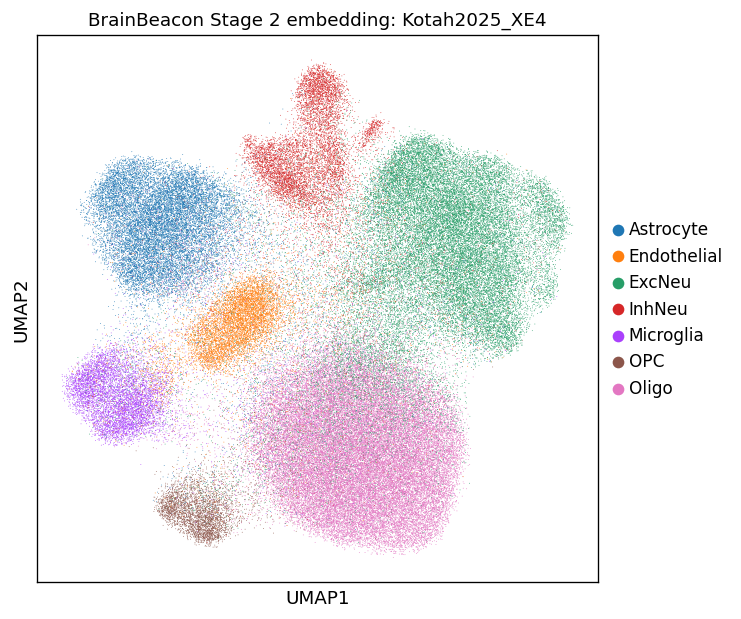

/tmp/ipykernel_1032688/1852572745.py:12: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


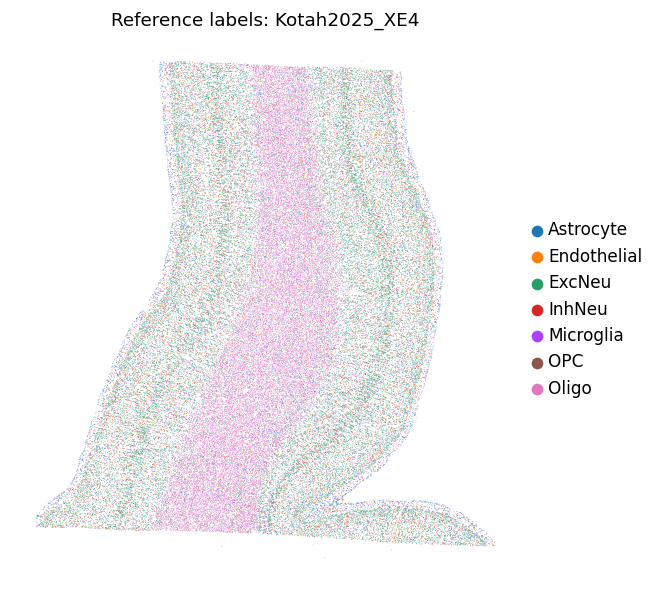

In [7]:
sc.pp.neighbors(
    adata,
    use_rep="X_emb",
    n_neighbors=15,
    metric="euclidean",
    key_added="brainbeacon_neighbors",
)
sc.tl.umap(adata, neighbors_key="brainbeacon_neighbors", random_state=0)

if label_key is not None:
    sc.pl.umap(adata, color=label_key, title=f"BrainBeacon Stage 2 embedding: {slice_id}")
    sc.pl.spatial(
        adata,
        color=label_key,
        img_key=None,
        spot_size=12,
        frameon=False,
        title=f"Reference labels: {slice_id}",
    )
else:
    sc.pl.umap(adata, title=f"BrainBeacon Stage 2 embedding: {slice_id}")
    print("No reference label column was found; skipping the labeled spatial plot.")


## 8. Optional clustering sanity check

This step is optional and requires reference labels. It clusters `X_emb`, targets the observed number of reference categories for evaluation, and reports ARI, NMI, and spatial neighborhood agreement. The reference labels are used only to define the evaluation target and calculate metrics; they are not used to generate the BrainBeacon embeddings.

For exact paper-level benchmarking across methods and datasets, use the dedicated scripts under `downstream_tasks/cell_clustering/scripts/`.


/raid/zhangchengming/BrainBeacon-master/brainbeacon/evaluation/clustering.py:288: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(


,n_cells,n_clusters_true,n_clusters_pred,resolution,ari,nmi,neighbor_agreement
0,123298,7,7,0.42,0.711052,0.674158,0.379971


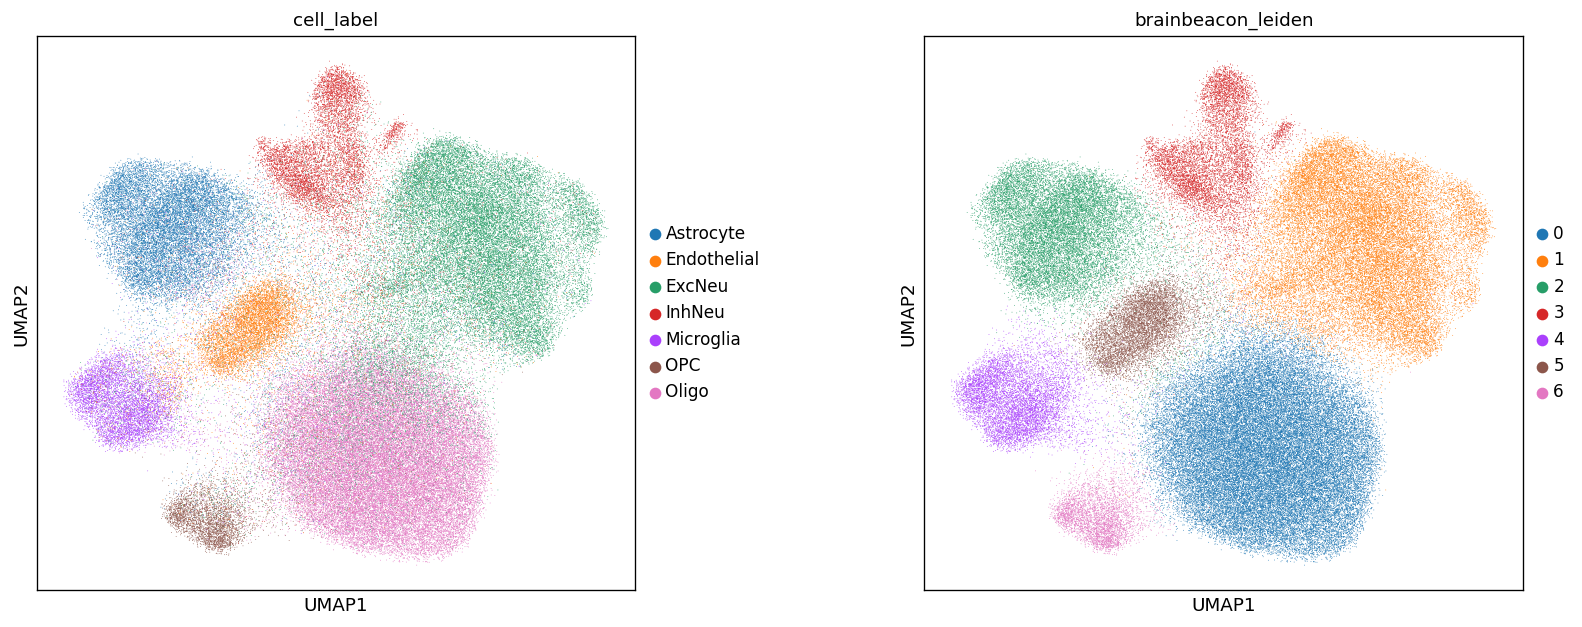

/tmp/ipykernel_1032688/3123455151.py:47: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


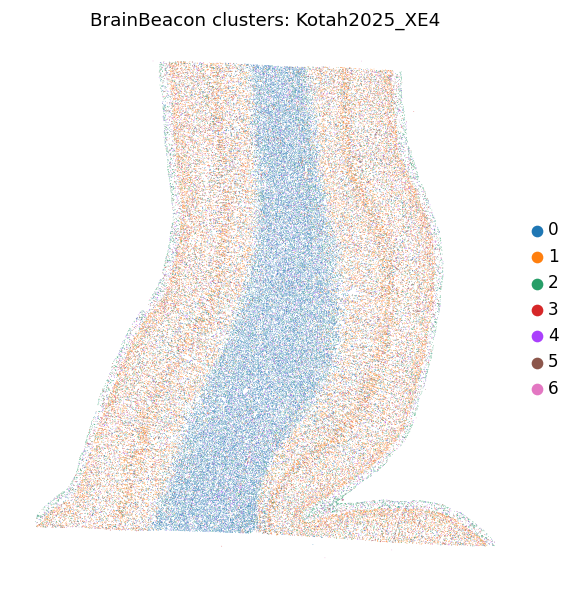

In [8]:
if label_key is None:
    print("No reference labels are available; skipping quantitative evaluation.")
else:
    from brainbeacon.evaluation.clustering import cluster_leiden
    from brainbeacon.evaluation.metrics import compute_clustering_metrics, compute_spatial_metrics

    label_text = adata.obs[label_key].astype(str)
    valid_labels = adata.obs[label_key].notna() & ~label_text.str.lower().isin(["unannotated", "unknown", "nan"])
    adata_eval = adata[valid_labels].copy()
    y_true = adata_eval.obs[label_key].astype(str).to_numpy()
    target_n_clusters = int(pd.Series(y_true).nunique())

    y_pred, cluster_info = cluster_leiden(
        X=np.asarray(adata_eval.obsm["X_emb"]),
        target_n_clusters=target_n_clusters,
        resolution=1.0,
        n_neighbors=15,
        metric="euclidean",
        random_state=0,
        pca_dim=None,
        max_iterations=10,
        return_info=True,
    )
    adata_eval.obs["brainbeacon_leiden"] = pd.Categorical(y_pred.astype(str))

    metrics = compute_clustering_metrics(y_true, y_pred, metrics=["ari", "nmi"])
    metrics.update(
        compute_spatial_metrics(
            y_pred=y_pred,
            spatial=np.asarray(adata_eval.obsm["spatial"]),
            metrics=["neighbor_agreement"],
            n_neighbors=15,
        )
    )
    metrics.update(
        {
            "n_cells": adata_eval.n_obs,
            "n_clusters_true": target_n_clusters,
            "n_clusters_pred": int(cluster_info["n_clusters"]),
            "resolution": float(cluster_info["resolution"]),
        }
    )

    metric_order = ["n_cells", "n_clusters_true", "n_clusters_pred", "resolution", "ari", "nmi", "neighbor_agreement"]
    display(pd.DataFrame([{key: metrics[key] for key in metric_order}]))
    sc.pl.umap(adata_eval, color=[label_key, "brainbeacon_leiden"], wspace=0.35)
    sc.pl.spatial(
        adata_eval,
        color="brainbeacon_leiden",
        img_key=None,
        spot_size=12,
        frameon=False,
        title=f"BrainBeacon clusters: {slice_id}",
    )


## Notes

- `do_fit=False` performs frozen zero-shot inference; no target-dataset adaptation is used.
- `bb_emb` is the Stage 1 cell representation.
- `X_emb` is the final Stage 2 representation used for downstream neighborhood-graph construction and clustering.
- `X_pred` is reconstructed expression and is not used to construct the clustering graph in this tutorial.
- The pipeline writes compressed Stage 1 and Stage 2 embedding files to `output_dir`.
